# Recommender System

This project focuses on designing and evaluating a movie recommendation system that predicts the ratings a user would give to movies they haven't rated yet. Using traditional machine learning algorithms (excluding deep learning models), the goal is to build a model that effectively predicts ratings for the test set, providing personalized movie recommendations.


In [55]:
!pip install xgboost
!pip install lightgbm
!pip install pandas
!pip install sklearn
!pip install matplotlib


[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  python setup.py egg_info did not run successfully.
  exit code: 1
  
  [15 lines of output]
  The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
  rather than 'sklearn' for pip commands.
  
  Here is how to fix this error in the main use cases:
  - use 'pip install scikit-learn' rather than 'pip install sklearn'
  - replace 'sklearn' by 'scikit-learn' in your pip requirements files
    (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
  - if the 'sklearn' package is used by one of your dependencies,
    it would be great if you take some time to track which package uses
    'sklearn' instead of 'scikit-learn' and report it to their issue tracker
  - as a last resort, set the environment variable
    SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
  
  More information is available at
  https://github.com/scikit-learn/sklearn-pypi-package
  [end of output]
  
  note: This error originates from a subpr


[notice] A new release of pip available: 22.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- `import pandas as pd`: Imports the pandas library, commonly used for data manipulation and analysis, especially with tabular data (e.g., DataFrames).
- `import numpy as np`: Imports the numpy library, used for numerical operations and handling arrays and matrices.
- `from sklearn.preprocessing import LabelEncoder`: Imports LabelEncoder from scikit-learn, used to convert categorical labels into numerical form.
- `from sklearn.model_selection import KFold`: Imports KFold from scikit-learn, used for cross-validation by splitting data into K subsets for training and testing.
- `from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score`: Imports several evaluation metrics:
  - `mean_squared_error`: Measures the average squared difference between predicted and actual values.
  - `mean_absolute_error`: Measures the average absolute difference between predicted and actual values.
  - `r2_score`: Measures the proportion of variance explained by the model (coefficient of determination).
- `from lightgbm import LGBMRegressor, early_stopping, log_evaluation`: 
  - `LGBMRegressor`: A gradient boosting model from LightGBM, used for regression tasks.
  - `early_stopping`: A method to stop training early if the model’s performance doesn’t improve on the validation set.
  - `log_evaluation`: A function to log the evaluation metrics during training.
- `import matplotlib.pyplot as plt`: Imports the matplotlib library for creating static, animated, and interactive visualizations, especially used for plotting graphs.

In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
import matplotlib.pyplot as plt

The code loads three datasets (`ratings`, `trust`, `test`) from CSV files and displays the first few rows of each. It checks for missing values in the `ratings` and `trust` datasets and prints the count of missing values. If the `ratings` are not already between 0 and 1, it normalizes the values and stores them in a new column called `label_normalized`. Finally, it displays the updated `ratings` dataset.

In [57]:
ratings = pd.read_csv('train_data_movie_rate.csv')
trust = pd.read_csv('train_data_movie_trust.csv')
test = pd.read_csv('test_data.csv')

print("Ratings Dataset Preview:")
display(ratings.head())

print("Trust Dataset Preview:")
display(trust.head())

print("Test Dataset Preview:")
display(test.head())

print("\nMissing Values in Ratings Dataset:")
print(ratings.isnull().sum())

print("\nMissing Values in Trust Dataset:")
print(trust.isnull().sum())

rating_min = ratings['label'].min()
rating_max = ratings['label'].max()

if not (rating_min >= 0 and rating_max <= 1):
    ratings['label_normalized'] = (ratings['label'] - rating_min) / (rating_max - rating_min)
    print("\nRatings have been normalized between 0 and 1.")
else:
    ratings['label_normalized'] = ratings['label']
    print("\nRatings are already between 0 and 1, no normalization needed.")

display(ratings.head())

Ratings Dataset Preview:


,id,user_id,item_id,label
0,1,1,1,2.0
1,2,1,2,4.0
2,3,1,3,3.5
3,4,1,4,3.0
4,5,1,5,4.0


Trust Dataset Preview:


,id,user_id_trustor,user_id_trustee,trust_value
0,1,2,966,1
1,2,2,104,1
2,3,5,1509,1
3,4,6,1192,1
4,5,7,1510,1


Test Dataset Preview:


,id,user_id,item_id
0,1,6,211
1,2,6,7
2,3,16,2
3,4,16,4
4,5,16,11



Missing Values in Ratings Dataset:
id         0
user_id    0
item_id    0
label      0
dtype: int64

Missing Values in Trust Dataset:
id                 0
user_id_trustor    0
user_id_trustee    0
trust_value        0
dtype: int64

Ratings have been normalized between 0 and 1.


,id,user_id,item_id,label,label_normalized
0,1,1,1,2.0,0.428571
1,2,1,2,4.0,1.000000
2,3,1,3,3.5,0.857143
3,4,1,4,3.0,0.714286
4,5,1,5,4.0,1.000000


The code prepares data by encoding user and item IDs, then creates fetures like user/item averages, interactions, and trust scores. It trains a LightGBM model using 5-fold cross-validation, with early stopping and evaluation logging. After training, it calculates and prints performance metrics (RMSE, MAE, MSE, R²) based on out-of-fold predictions.

In [58]:
all_users = pd.concat([
    ratings['user_id'],
    trust['user_id_trustor'],
    trust['user_id_trustee'],
    test['user_id']
]).unique()

all_items = pd.concat([
    ratings['item_id'],
    test['item_id']
]).unique()

user_encoder = LabelEncoder().fit(all_users)
item_encoder = LabelEncoder().fit(all_items)

ratings['user_encoded'] = user_encoder.transform(ratings['user_id'])
ratings['item_encoded'] = item_encoder.transform(ratings['item_id'])

trust['user_encoded'] = user_encoder.transform(trust['user_id_trustor'])
trust['friend_encoded'] = user_encoder.transform(trust['user_id_trustee'])

user_mean = ratings.groupby('user_encoded')['label_normalized'].mean()
item_mean = ratings.groupby('item_encoded')['label_normalized'].mean()
user_count = ratings.groupby('user_encoded').size()
item_count = ratings.groupby('item_encoded').size()
user_trust_score = trust.groupby('user_encoded')['trust_value'].mean()
trustor_count = trust.groupby('user_encoded').size()
global_mean = ratings['label_normalized'].mean()

ratings['user_mean'] = ratings['user_encoded'].map(user_mean)
ratings['item_mean'] = ratings['item_encoded'].map(item_mean)
ratings['user_interactions'] = ratings['user_encoded'].map(user_count)
ratings['item_popularity'] = ratings['item_encoded'].map(item_count)
ratings['trust_score'] = ratings['user_encoded'].map(user_trust_score).fillna(trust['trust_value'].mean())
ratings['trustor_count'] = ratings['user_encoded'].map(trustor_count).fillna(0)
ratings['global_mean'] = global_mean

ratings['user_item'] = ratings['user_encoded'].astype(str) + "_" + ratings['item_encoded'].astype(str)
ratings['user_item'] = LabelEncoder().fit_transform(ratings['user_item'])

features = [
    'user_encoded', 'item_encoded', 'user_mean', 'item_mean',
    'user_interactions', 'item_popularity', 'trust_score',
    'trustor_count', 'global_mean', 'user_item'
]
X = ratings[features]
y = ratings['label_normalized']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model = LGBMRegressor(
        n_estimators=6000,
        learning_rate=0.01,
        max_depth=25,
        num_leaves=555,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=1.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[early_stopping(stopping_rounds=50), log_evaluation(0)]
    )

    oof_preds[val_idx] = model.predict(X_val)
    models.append(model)

rmse = np.sqrt(mean_squared_error(y, oof_preds))
mae = mean_absolute_error(y, oof_preds)
r2 = r2_score(y, oof_preds)
mse = mean_squared_error(y, oof_preds)

print(f"CV RMSE: {rmse:.4f}")
print(f"CV MAE: {mae:.4f}")
print(f"CV MSE: {mse:.4f}")
print(f"CV R^2: {r2:.4f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[356]	valid_0's l2: 0.0450129
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[310]	valid_0's l2: 0.0426459
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[316]	valid_0's l2: 0.044338
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[304]	valid_0's l2: 0.0428436
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[311]	valid_0's l2: 0.0444757
CV RMSE: 0.2094
CV MAE: 0.1601
CV MSE: 0.0439
CV R^2: 0.3592


The code encodes test data using previously trained encoders, maps precomputed features, handles missing values, and makes predictions with the trained models. The predictions are rescaled back to the original range and saved in a submission file (`submission.csv`).

In [59]:
test['user_encoded'] = test['user_id'].map(lambda x: user_encoder.transform([x])[0] if x in user_encoder.classes_ else -1)
test['item_encoded'] = test['item_id'].map(lambda x: item_encoder.transform([x])[0] if x in item_encoder.classes_ else -1)

test['user_mean'] = test['user_encoded'].map(user_mean)
test['item_mean'] = test['item_encoded'].map(item_mean)
test['user_interactions'] = test['user_encoded'].map(user_count)
test['item_popularity'] = test['item_encoded'].map(item_count)
test['trust_score'] = test['user_encoded'].map(user_trust_score).fillna(trust['trust_value'].mean())
test['trustor_count'] = test['user_encoded'].map(trustor_count).fillna(0)
test['global_mean'] = global_mean

test['user_item'] = test['user_encoded'].astype(str) + "_" + test['item_encoded'].astype(str)
test['user_item'] = LabelEncoder().fit_transform(test['user_item'])

test.fillna(0, inplace=True)

X_test = test[features]

test_preds = np.mean([m.predict(X_test) for m in models], axis=0)
test_preds_rescaled = test_preds * (rating_max - rating_min) + rating_min

submission = pd.DataFrame({
    'id': test['id'],
    'label': test_preds_rescaled
})
submission.to_csv('submission.csv', index=False)
print("✅ Submission file saved as 'submission.csv'")
display(submission.head())

✅ Submission file saved as 'submission.csv'


,id,label
0,1,3.808842
1,2,3.819839
2,3,3.567631
3,4,3.611319
4,5,3.673402


The code visualizes feature importances by sorting them and creating a horizontal bar plot to display the most important features, labeled with their names.

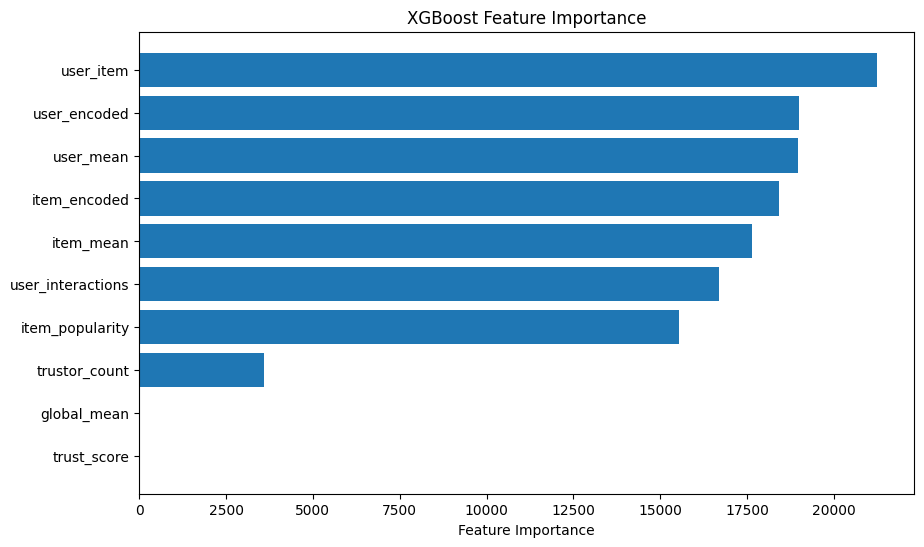

In [60]:
feature_importances = model.feature_importances_
sorted_idx = np.argsort(feature_importances)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], align='center')
plt.yticks(np.arange(len(sorted_idx)), [features[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance')
plt.show()